### Análisis de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dev_path = "data/raw/casas_dev.csv"
test_path = "data/raw/casas_test.csv"

casas_dev_df = pd.read_csv(dev_path)
casas_test_df = pd.read_csv(test_path)

In [3]:
print('shape = ', casas_dev_df.shape)
casas_dev_df.sample(5)

shape =  (900, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
392,84.0,m2,0,1,10.0,178.0,-34.602019,-58.391077,2.0
351,1518.0,sqft,0,0,2.0,1210.0,40.707744,-74.004189,4.0
618,86.0,m2,1,0,19.0,153.0,-34.569853,-58.344754,2.0
186,123.0,m2,1,0,11.0,243.0,-34.617028,-58.354252,4.0
481,138.0,m2,0,0,NaN,209.0,-34.551472,-58.332377,4.0


In [4]:
print('shape = ', casas_test_df.shape)
casas_test_df.sample(5)

shape =  (100, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
21,635.0,sqft,0,0,9.0,424.0,40.722805,-74.055818,2.0
30,124.0,m2,0,0,3.0,233.0,-34.673129,-58.329864,4.0
54,122.0,m2,1,0,7.0,247.0,-34.573742,-58.433770,4.0
65,124.0,m2,1,0,19.0,218.0,-34.564171,-58.426656,4.0
93,100.0,m2,1,0,17.0,168.0,-34.673148,-58.406428,3.0


# 1) Exploración de datos

El orden de los incisos correspondientes al ejercicio 1 fueron alterados por cuestiones de eficacia y buenas prácticas.

##### 1.1 primera parte) -> analizamos los valores faltantes en los datasets.

In [5]:
from src.utils import missing_percentages, missing_values

In [6]:
print("Dev Set")
missing_values(casas_dev_df)
missing_percentages(casas_dev_df)


Dev Set

Valores faltantes por columna:
area            0
area_units      0
is_house        0
has_pool        0
age           130
price           0
lat             0
lon             0
rooms          72
dtype: int64
Valores NaN en 'age': 130 sobre un total de 900 filas (14.44%)
Valores NaN en 'rooms': 72 sobre un total de 900 filas (8.00%)


Dropear 14.44% y/o 8% de los datos por una feature faltante sería desperdiciar mucha información por lo que intentaremos estimar estos valores faltantes. Para eso, anaelicemos el resto de las features y sus correlaciones.

In [7]:
print("Test Set")
missing_values(casas_test_df)
missing_percentages(casas_test_df)

Test Set

Valores faltantes por columna:
area           0
area_units     0
is_house       0
has_pool       0
age           16
price          0
lat            0
lon            0
rooms          4
dtype: int64
Valores NaN en 'age': 16 sobre un total de 100 filas (16.00%)
Valores NaN en 'rooms': 4 sobre un total de 100 filas (4.00%)


##### Revisión de unidades

In [8]:
print(casas_dev_df['area_units'].value_counts())

area_units
m2      463
sqft    437
Name: count, dtype: int64


Conversión/unificación de unidades

In [9]:
print(casas_test_df['area_units'].value_counts())

area_units
m2      53
sqft    47
Name: count, dtype: int64


In [10]:
from src.preprocessing import area_units_conversion

In [11]:
units_converted_dev_df = area_units_conversion(casas_dev_df)

In [12]:
units_converted_test_df = area_units_conversion(casas_test_df)

Ahora sí podemos visualizar las distribuciones de dev

(resolveremos los valores faltantes NaNs más adelante)

##### 1.2)

In [13]:
from src.plotting import plot_distributions, plot_scatter_matrix, plot_correlation

#### Dev Set

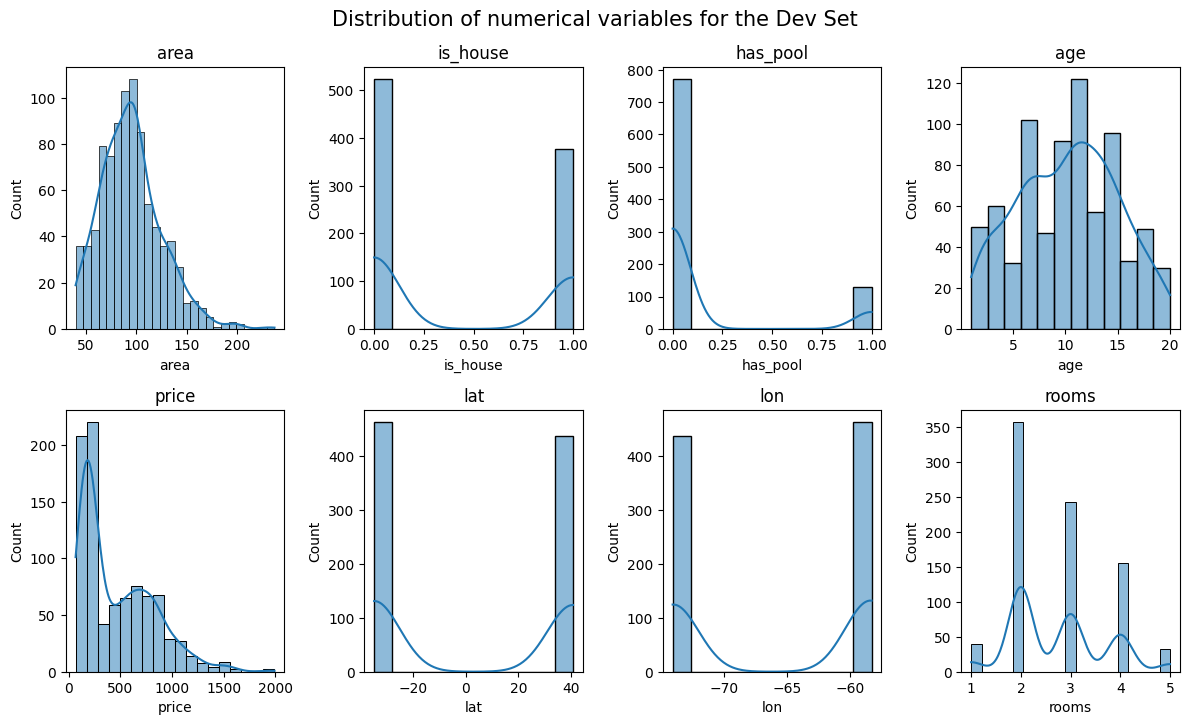

In [14]:
plot_distributions(units_converted_dev_df, "Dev")

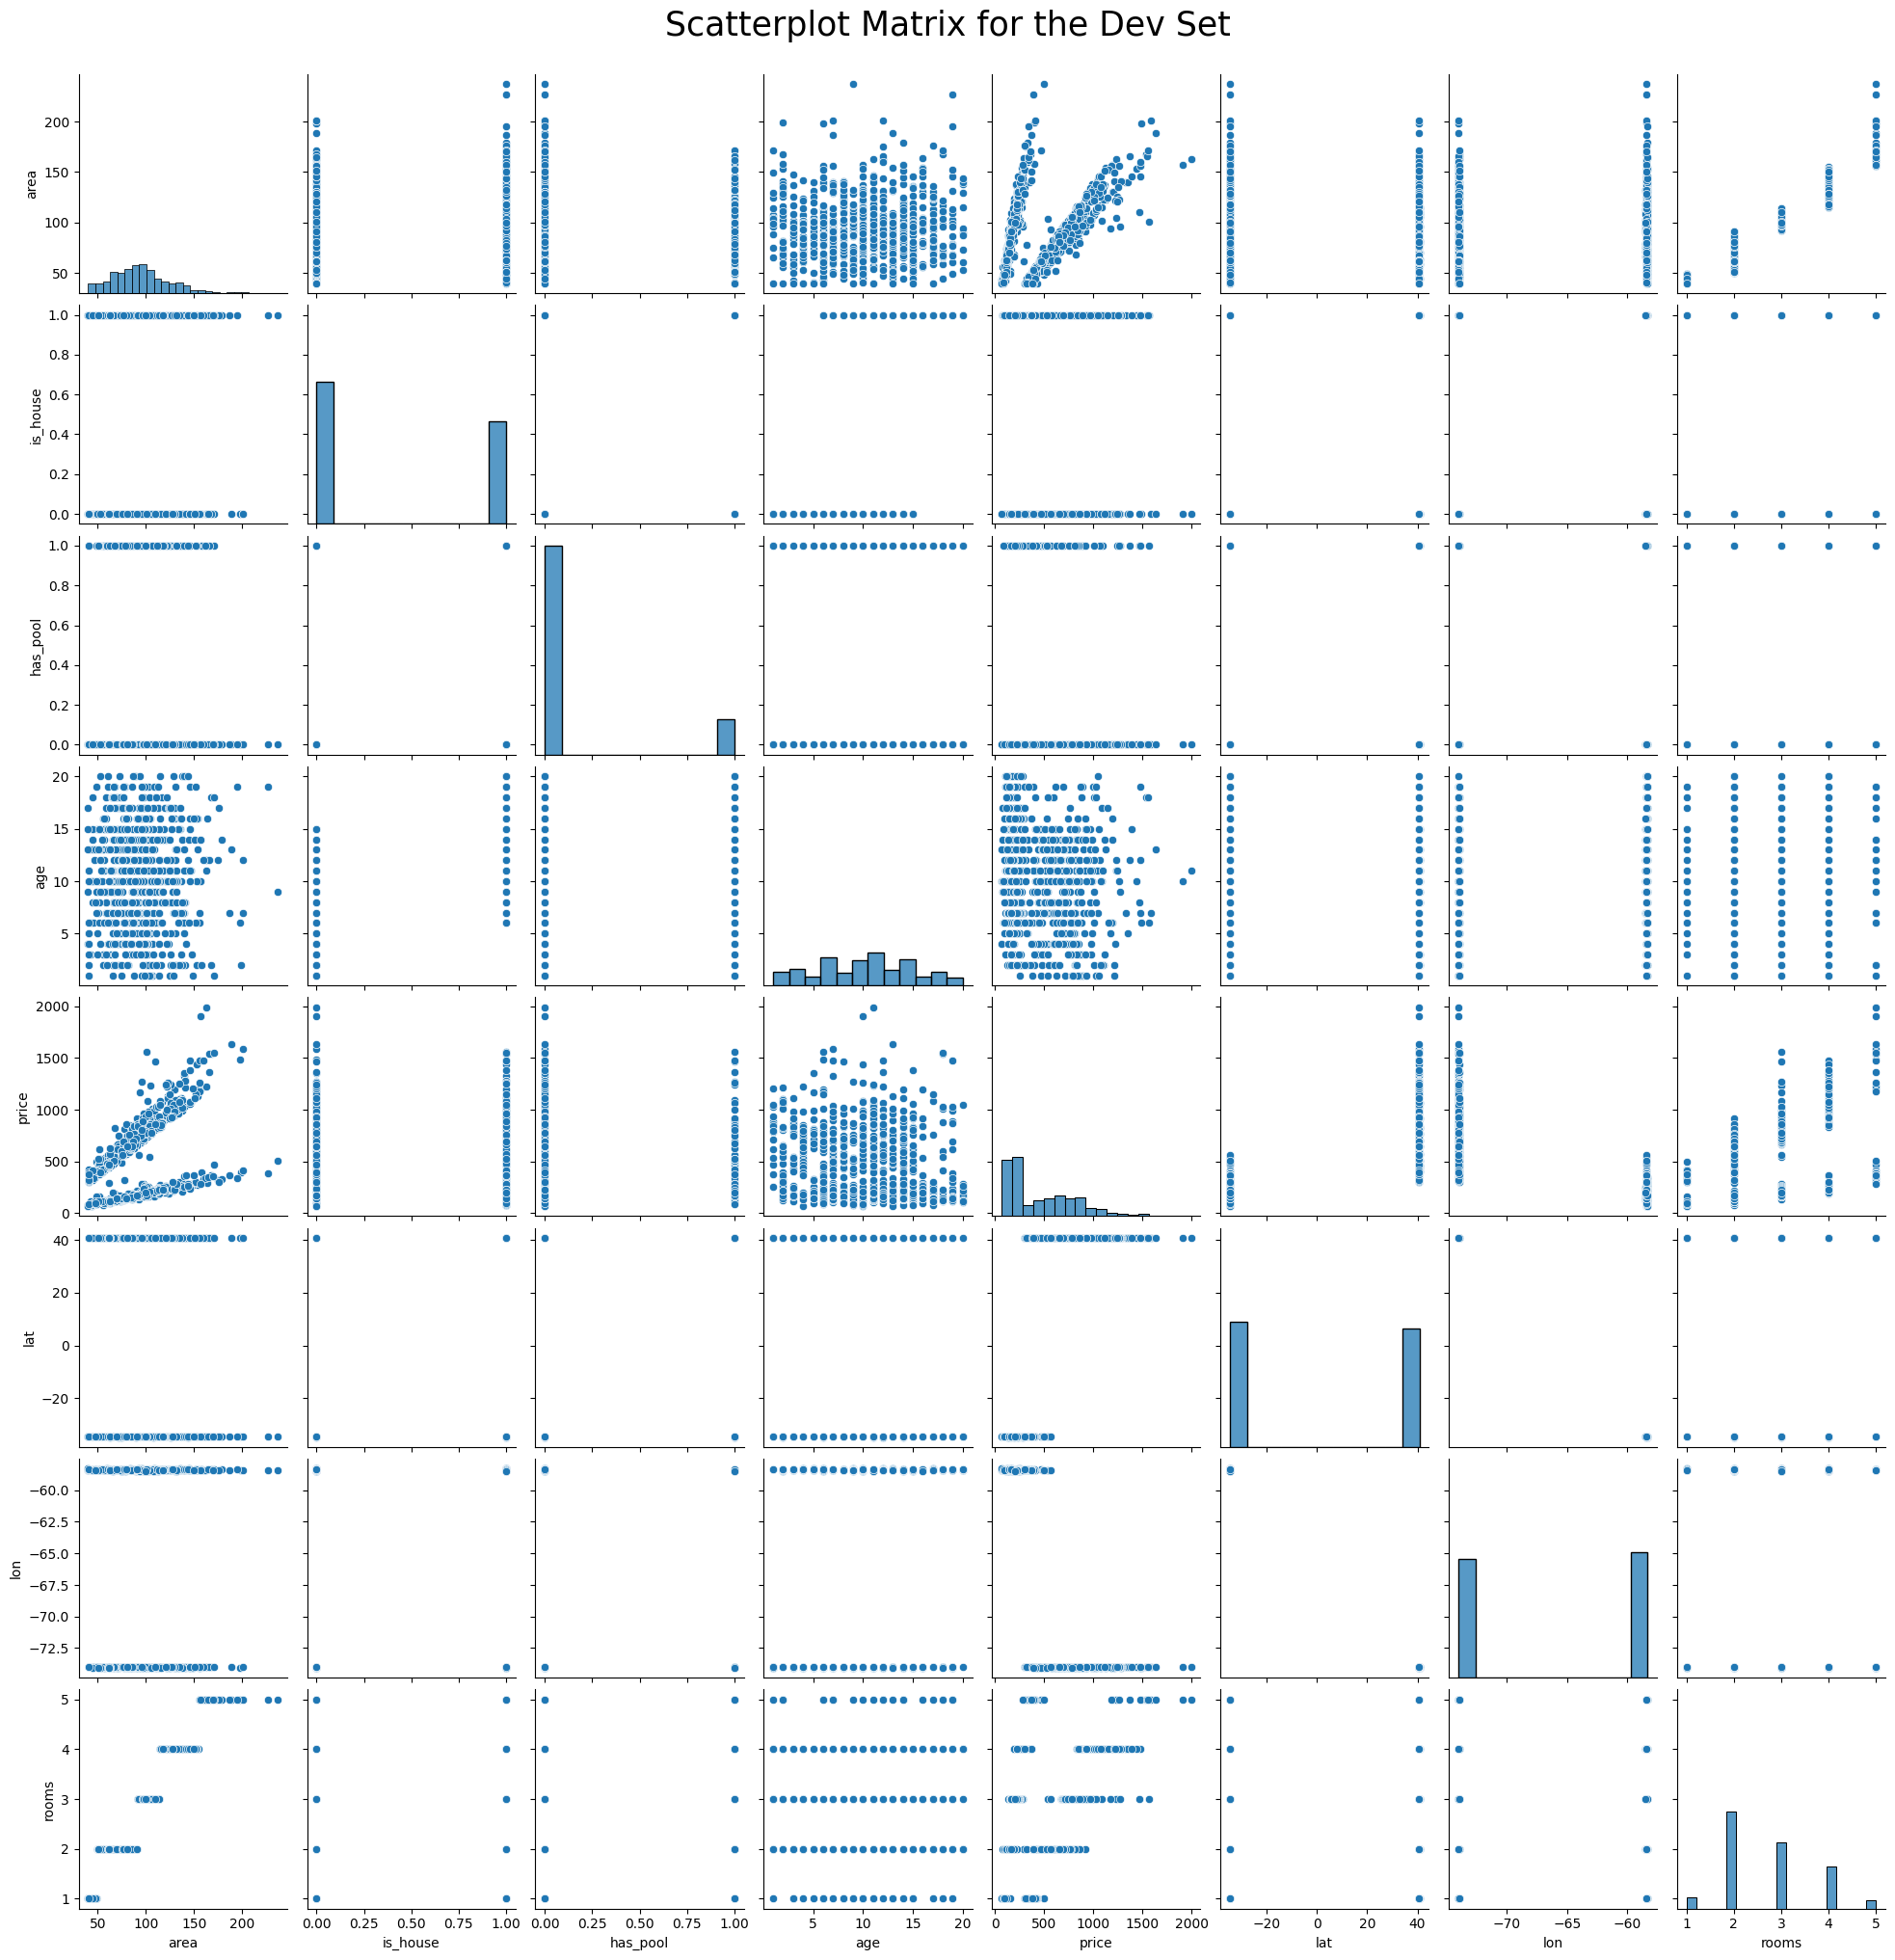

In [15]:
plot_scatter_matrix(units_converted_dev_df, "Dev")

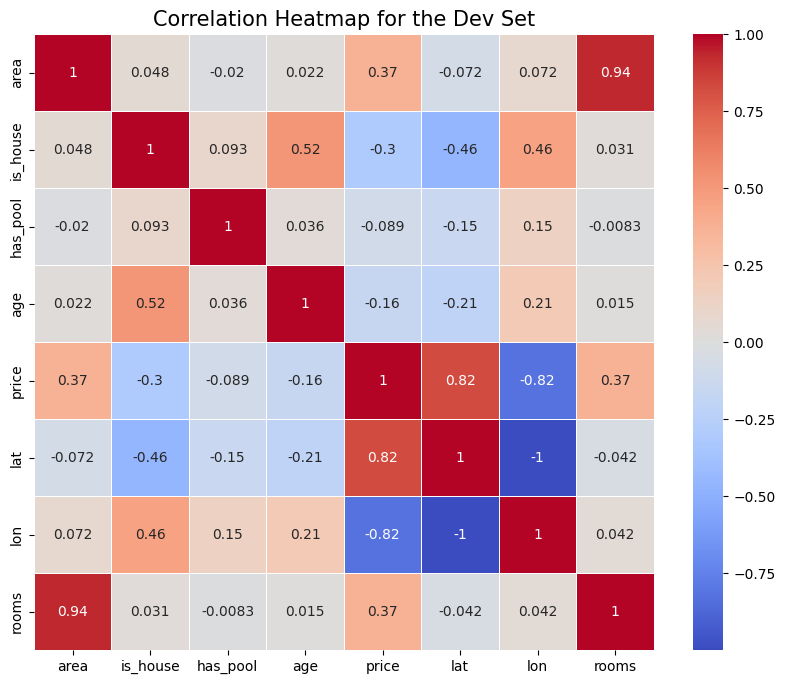

In [16]:
plot_correlation(units_converted_dev_df, "the Dev Set")

#### 1.3) Separación en Train y Validation

Para evitar leaking, separamos el dataset en train y validation antes de estandarizar/escalar los datos y acomodar los valores faltantes.

In [17]:
from src.data_splitting import split_and_save_train_val

In [18]:
casas_train_df, casas_val_df = split_and_save_train_val(units_converted_dev_df, "raw/casas_train.csv", "raw/casas_val.csv")

Train set: 720 rows, Validation set: 180 rows


La idea de estandarización/escalamiento que se va a usar es la siguiente:

#### estandarizamos o escalamos los datos según corresponde

hacemos estandarización (Z-score normalization) cuando asumimos que los datos provienenen de una distribución aproximadamente normal
$$x' = \frac{x - \mu}{\sigma}$$

Y hacemos reescalado cuando cuando los datos no son normales  
Una opción común es Min-Max Scaling:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

A partir de la observación de la distribución de las variables decido hacer lo siguiente:  

Estandarizo:  
age (aproximadamente normal), rooms (discreta pero la estandarización ayuda)  
(luego de resolver el problema de los NaNs)

Reescalo:   
area y price están sesgadas a la derecha (colas largas)  
la función log anda bien cuando los datos tienen una cola larga hacia la derecha $\rightarrow$ Comprime los valores altos y expande los valores bajos.  
price = log(price + 1) (y hago un ajuste inverso después de la predicción)  
area = log(area + 1) y después estandarizar  
El log hace que los valores grandes no dominen el modelo y mejora la linealidad

o min max...

No hago nada con las binarias: has_pool, is_house  
lat y lon las analizaremos más adelante con feature engenieering

aún no estandarizamos porque al hacer las regresiones para estimar las variables, voy a dividir el dataset de train a su vez en train, validation y test, entonces si estandarizo ahora estaría filtrando información de los datos. Pero dentro de las funciones, esta es la lógica usada para estandarizar los datos para conseguir los valores faltantes.

#### Solucionamos ahora los problemas de nulls

##### Rooms

-> idea: estimo la cantidad de rooms en base al área

visualizo la relación para ver qué regresión usar

In [19]:
from src.plotting import plot_rooms_vs_area

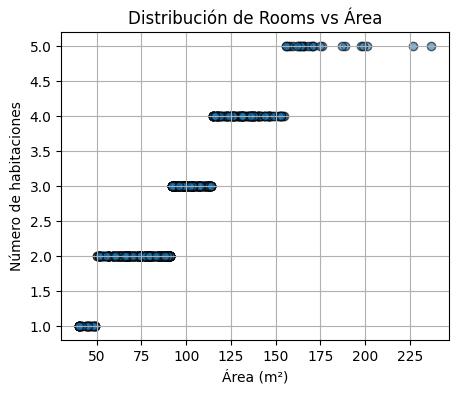

In [20]:
plot_rooms_vs_area(casas_train_df)

In [21]:
from src.models import predict_rooms_train_test, predict_rooms_no_split, complete_missing_rooms_values
from src.utils import missinng_values_in_column

In [22]:
print("Entrenamiento con Train set\n")
print("divididendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)")
predict_rooms_train_test(casas_train_df)
print("\nentrenando con todo el dataset de train_df")
W_d, b_d, mean_d, std_d = predict_rooms_no_split(casas_train_df)

# uso los pesos de train para predecir en todos los datasets!!
print("\nCompletando valores faltantes en todos los datasets con las métricas calculadas a partir de train_df")
casas_train_rooms_complete = complete_missing_rooms_values(casas_train_df, W_d, b_d, mean_d, std_d)
casas_val_rooms_complete = complete_missing_rooms_values(casas_val_df, W_d, b_d, mean_d, std_d)
casas_test_rooms_complete = complete_missing_rooms_values(casas_test_df, W_d, b_d, mean_d, std_d)

print("\nChequeo")
print("Train:", missinng_values_in_column(casas_train_rooms_complete, 'rooms'))
print("Validation:", missinng_values_in_column(casas_val_rooms_complete, 'rooms'))
print("Test:", missinng_values_in_column(casas_test_rooms_complete, 'rooms'))


Entrenamiento con Train set

divididendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)
mean_train [94.31426177]
Época 0, Pérdida Train: 0.3214, Pérdida Val: 0.3211
Época 5000, Pérdida Train: 0.0578, Pérdida Val: 0.0564
Época 10000, Pérdida Train: 0.0446, Pérdida Val: 0.0428
Época 15000, Pérdida Train: 0.0385, Pérdida Val: 0.0363
Época 20000, Pérdida Train: 0.0348, Pérdida Val: 0.0322
Época 25000, Pérdida Train: 0.0322, Pérdida Val: 0.0294
Precisión en el conjunto de prueba de train_df: 0.9774

entrenando con todo el dataset de train_df
Época 0, Pérdida Train: 0.3228, Pérdida Val: 0.3228
Época 5000, Pérdida Train: 0.0572, Pérdida Val: 0.0555
Época 10000, Pérdida Train: 0.0442, Pérdida Val: 0.0432
Época 15000, Pérdida Train: 0.0381, Pérdida Val: 0.0376
Época 20000, Pérdida Train: 0.0344, Pérdida Val: 0.0343
Época 25000, Pérdida Train: 0.0318, Pérdida Val: 0.0320

Completando valores faltantes en todos los datasets con las métrica

In [23]:
casas_train_rooms_complete.sample(15)

,area,is_house,has_pool,age,price,lat,lon,rooms
637,126.000000,0,1,5.0,249.0,-34.631831,-58.364829,3.0
672,125.976644,0,0,2.0,1010.0,40.720196,-74.026656,4.0
465,96.000000,0,0,5.0,169.0,-34.619525,-58.435829,2.0
713,66.000000,1,1,18.0,142.0,-34.587108,-58.360103,2.0
2,61.966388,0,0,7.0,464.0,40.669863,-74.029414,2.0
854,91.974099,1,0,16.0,843.0,40.681358,-73.986265,3.0
845,82.962495,1,0,17.0,757.0,40.709092,-73.975902,2.0
882,128.020513,0,0,10.0,931.0,40.735897,-73.984350,4.0
400,92.000000,1,0,12.0,176.0,-34.576465,-58.451826,3.0
595,96.000000,1,0,11.0,187.0,-34.639193,-58.392013,3.0


verifico que las variables utilizadas normalizadas en la estimación estén en la escala real (area y rooms)

##### Age

estimo las ages que faltan, con aprendizaje supervisado utilizando las features que más correlacion en módulo tienen con age $\rightarrow$ is_house, price, area

In [24]:
from src.plotting import plot_age_vs

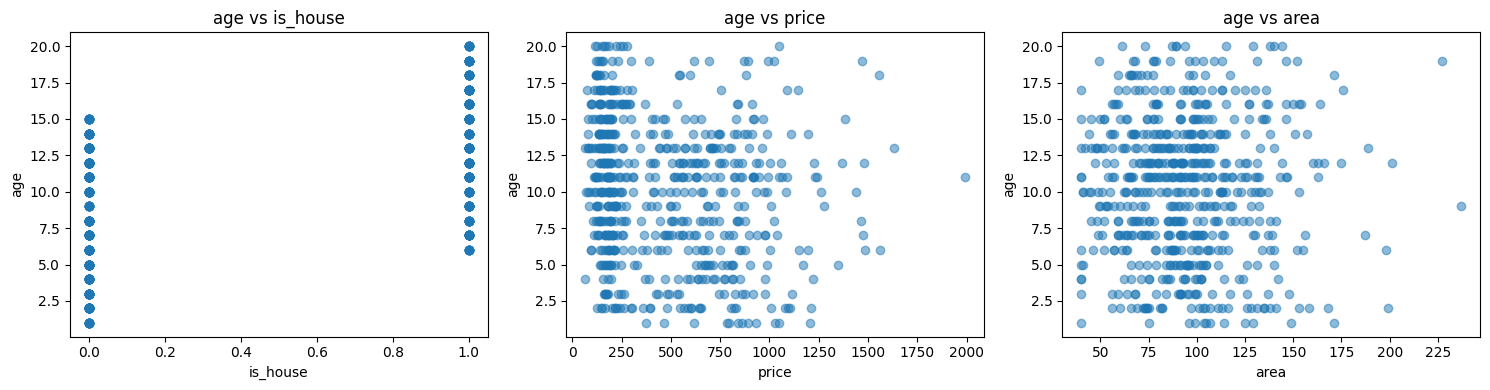

In [25]:
plot_age_vs(casas_train_rooms_complete, features=["is_house", "price", "area"])

In [26]:
from src.models import train_regression_for_age, complete_missing_age_values, evaluate_and_impute


In [27]:
features_seleccionadas = ['is_house', 'price', 'area']

print("Entrenamiento con Train set\n")
print("divididendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)")
evaluate_and_impute(casas_train_rooms_complete, features_seleccionadas, grado=1)

# Entrenar con todo el dataset disponible
theta_final, mean_final, std_final = train_regression_for_age(casas_train_rooms_complete, features_seleccionadas, grado=1)

casas_train_complete = complete_missing_age_values(casas_train_rooms_complete, theta_final, mean_final, std_final, features_seleccionadas, grado=1)
casas_val_complete = complete_missing_age_values(casas_val_rooms_complete, theta_final, mean_final, std_final, features_seleccionadas, grado=1)
casas_test_complete = complete_missing_age_values(casas_test_rooms_complete, theta_final, mean_final, std_final, features_seleccionadas, grado=1)

print("\nChequeo:")
print("Train:", missinng_values_in_column(casas_train_complete, 'age'))
print("Validation:", missinng_values_in_column(casas_val_complete, 'age'))
print("Test:", missinng_values_in_column(casas_test_complete, 'age'))

Entrenamiento con Train set

divididendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)
Train de Train_df RMSE: 4.0405
Validation de Train_df RMSE: 3.7051
Test de Train_df RMSE: 4.2650
107 valores faltantes en 'age' completados.
No hay valores faltantes en 'age'.
23 valores faltantes en 'age' completados.
16 valores faltantes en 'age' completados.

Chequeo:
Train: 0
Validation: 0
Test: 0


In [28]:
print("Valores faltantes después de la imputación:")
print("Train")
missing_values(casas_train_complete)
print("Validation")
missing_values(casas_val_complete)  
print("Test")
missing_values(casas_test_complete)

Valores faltantes después de la imputación:
Train

Valores faltantes por columna:
area        0
is_house    0
has_pool    0
age         0
price       0
lat         0
lon         0
rooms       0
dtype: int64
Validation

Valores faltantes por columna:
area        0
is_house    0
has_pool    0
age         0
price       0
lat         0
lon         0
rooms       0
dtype: int64
Test

Valores faltantes por columna:
area          0
area_units    0
is_house      0
has_pool      0
age           0
price         0
lat           0
lon           0
rooms         0
dtype: int64


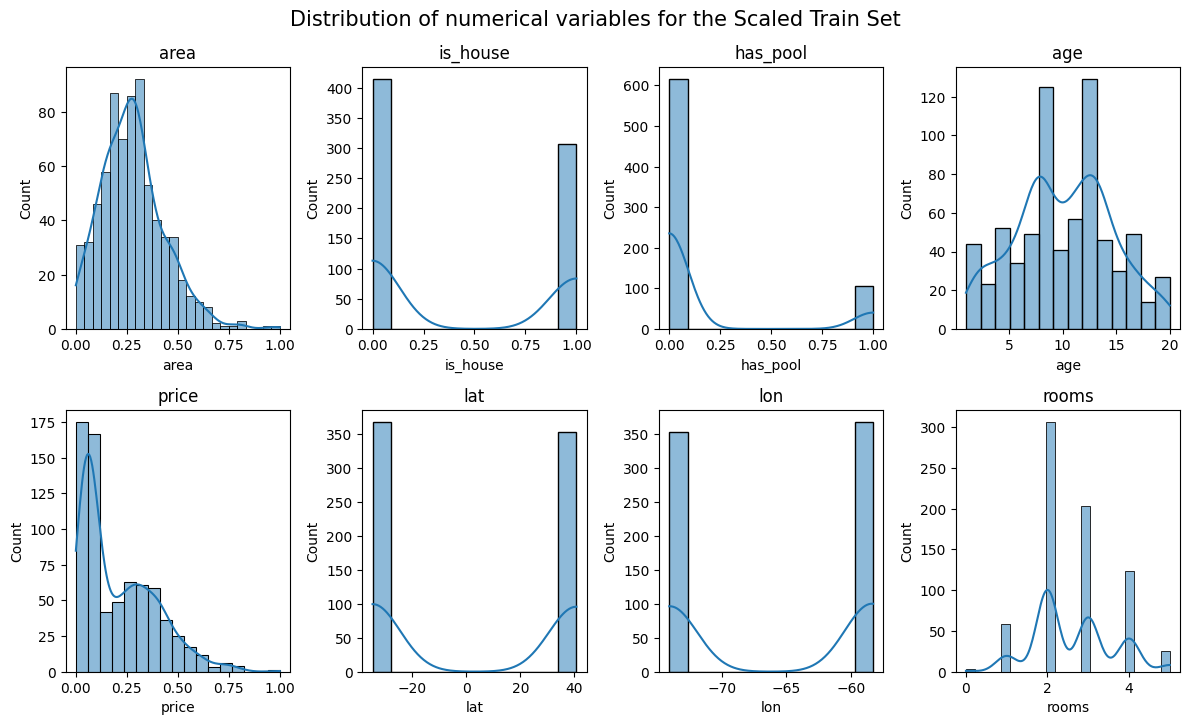

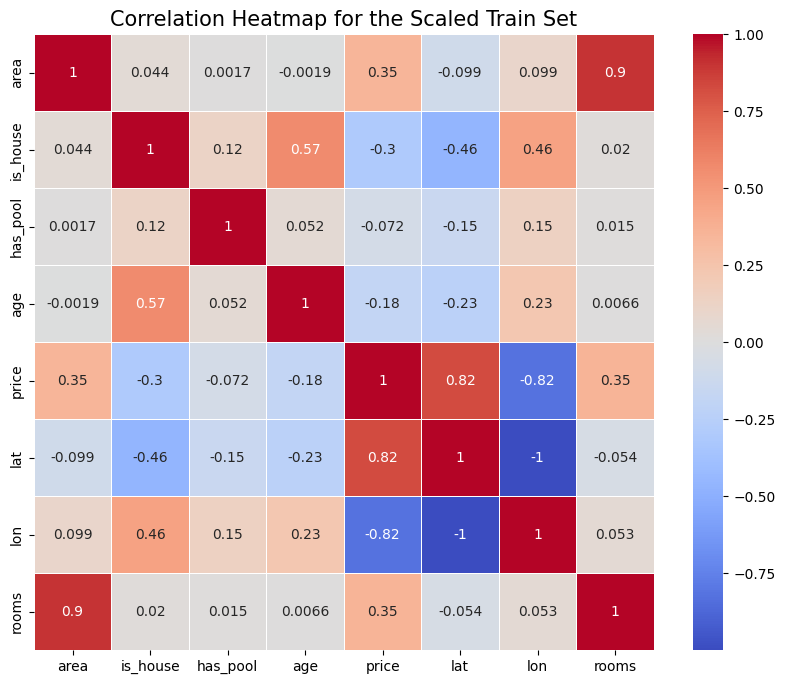

In [29]:
from src.preprocessing import compute_statistics, scale_df


train_stats = compute_statistics(casas_train_df)

casas_train_transformed = scale_df(casas_train_df, train_stats)
casas_val_transformed = scale_df(casas_val_df, train_stats) # uso las estadísticas de train!!!
casas_test_transformed = scale_df(units_converted_test_df, train_stats) # lo hago para poder estimar los valores faltantes, pero después vuelvo para atrás

plot_distributions(casas_train_transformed, "Scaled Train")
#(área y price siguen la misma distribución pero están entre 0 y 1)

plot_correlation(casas_train_transformed, "the Scaled Train Set")

In [30]:
complete_train_stats = compute_statistics(casas_train_complete)

casas_train_complete = scale_df(casas_train_complete, complete_train_stats, missing_values=True)
casas_val_complete = scale_df(casas_val_complete, complete_train_stats, missing_values=True)
casas_test_complete = scale_df(casas_test_complete, complete_train_stats, missing_values=True)

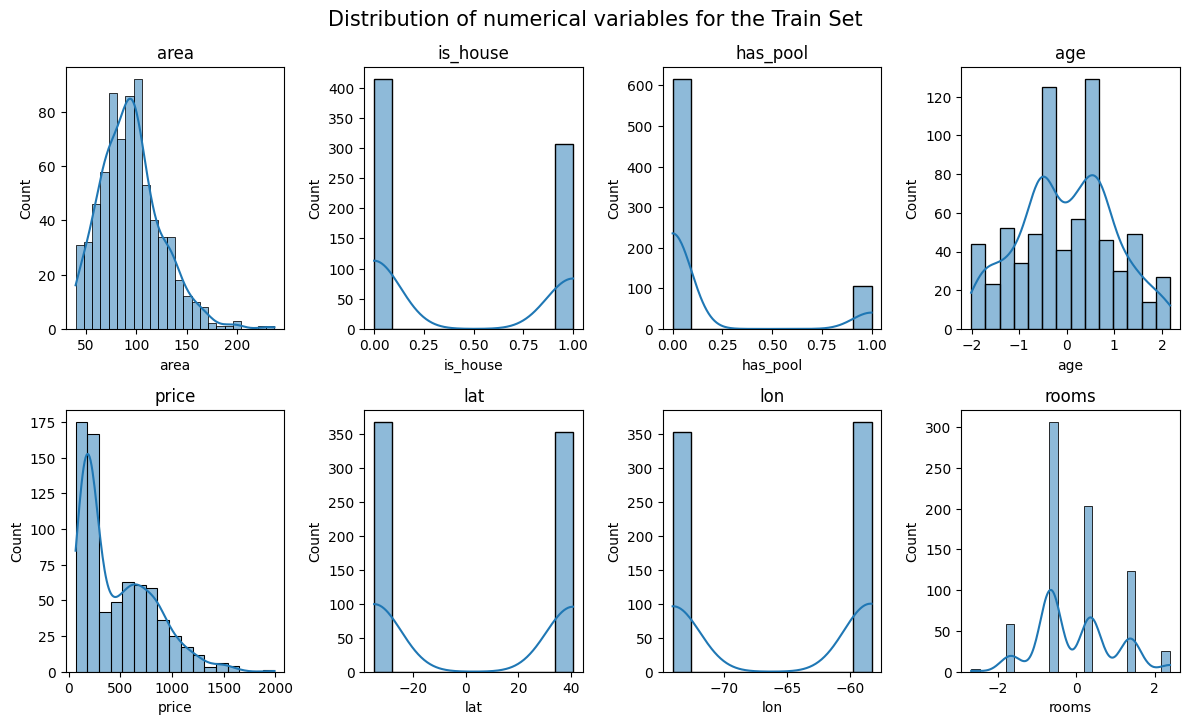

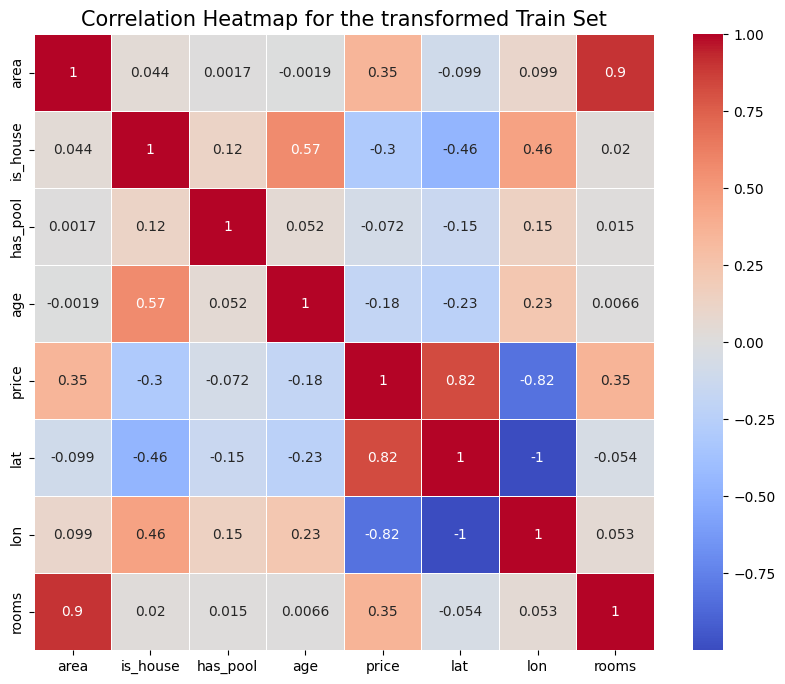

In [31]:
plot_distributions(casas_train_complete, "Train")
plot_correlation(casas_train_complete, "the transformed Train Set")

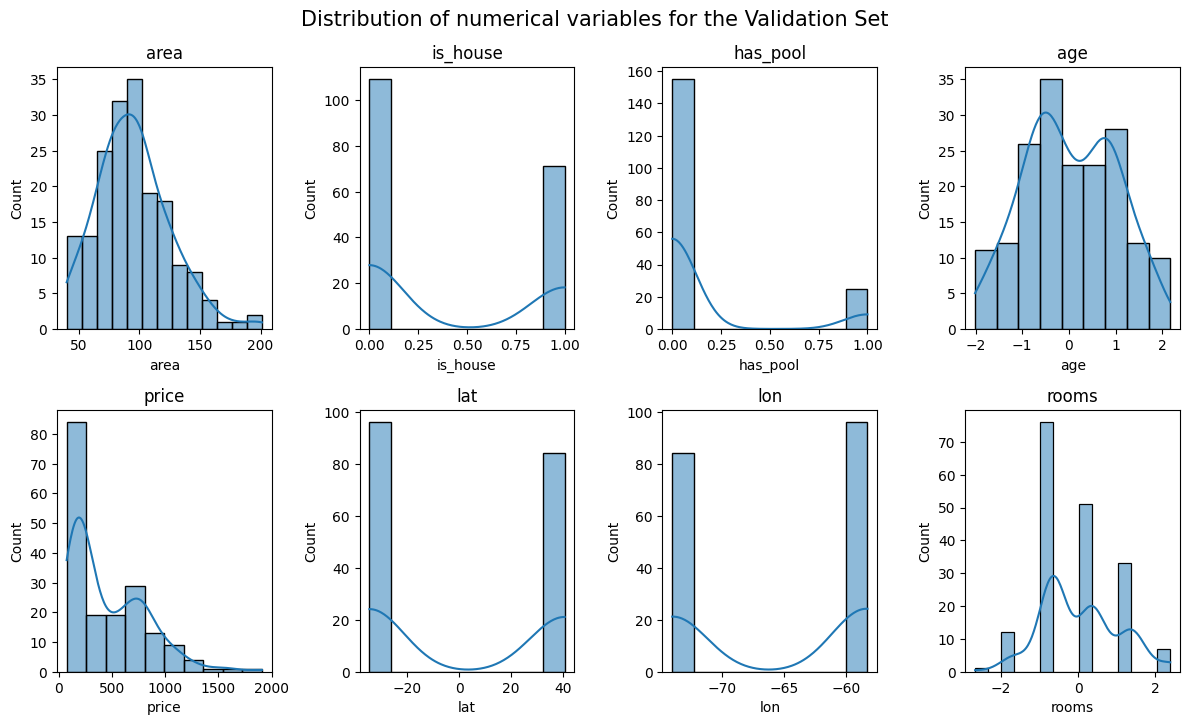

In [32]:
plot_distributions(casas_val_complete, "Validation")

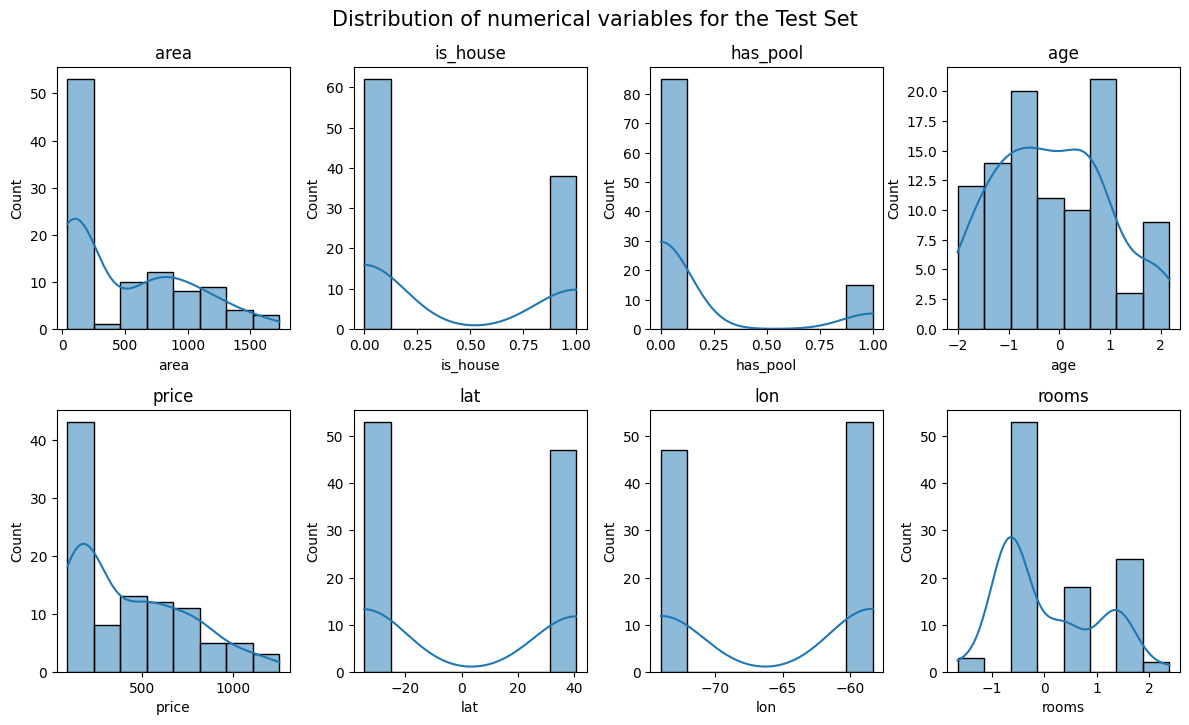

In [33]:
plot_distributions(casas_test_complete, "Test")

In [34]:
from src.utils import save_csv

save_csv(casas_train_complete, "data/processed/casas_train_filled_n_normalized.csv")
save_csv(casas_val_complete, "data/processed/casas_val_filled_n_normalized.csv")
save_csv(casas_test_complete, "data/processed/casas_test_filled_n_normalized.csv")


Dataset guardado como 'data/processed/casas_train_filled_n_normalized.csv'.
Dataset guardado como 'data/processed/casas_val_filled_n_normalized.csv'.
Dataset guardado como 'data/processed/casas_test_filled_n_normalized.csv'.


## 2)

2.1) implementación de la clase Linear Regression en src.models

2.2) implementación de RMSE en src.metrics

##### 2.3)

In [35]:
from src.models import LinearRegression
from src.utils import load_data

In [36]:
dir_base = "data/processed/"
train_path = dir_base + "casas_train_filled_n_normalized.csv"
validation_path = dir_base + "casas_val_filled_n_normalized.csv"
test_path = dir_base + "casas_test_filled_n_normalized.csv"



features = ["area", "is_house", "has_pool", "age", "lat", "lon", "rooms"] 
target = "price"

X_train, y_train = load_data(train_path, features, target)
X_val, y_val = load_data(validation_path, features, target)
X_test, y_test = load_data(test_path, features, target)



#### Prueba con una característica

In [37]:
X_train_1 = X_train[:, [0]]  # solo area
X_val_1 = X_val[:, [0]]  
X_test_1 = X_test[:, [0]]

##### Pseudoinversa

Error cuadrático medio (RMSE) en test: 5341570.7827


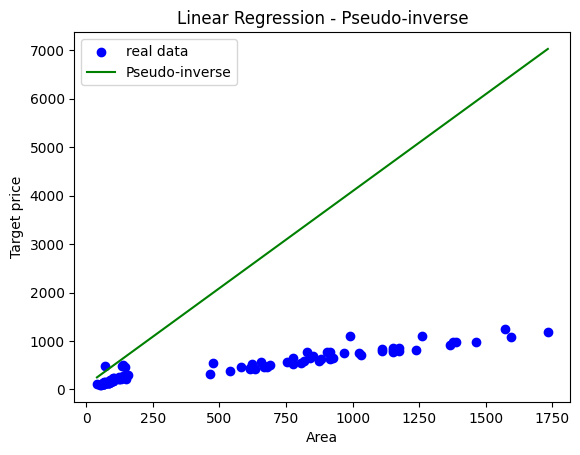

In [38]:
modelo_pseudo = LinearRegression(X_train_1, y_train, X_val_1, y_val)
modelo_pseudo.entrenar_pseudoinversa()
modelo_pseudo.evaluar(X_test_1, y_test)
modelo_pseudo.graficar_regresion_pseudoinversa(X_test_1, y_test, ["Area"])

##### Descenso por gradiente

Early stopping en epoch 11
Error cuadrático medio (RMSE) en test: 710935579697280419005769102941071051940125921509376.0000


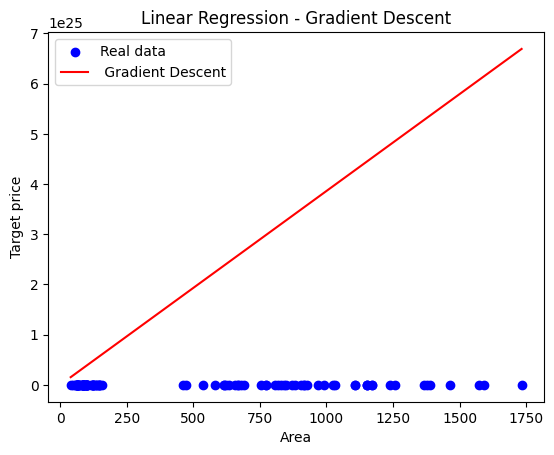

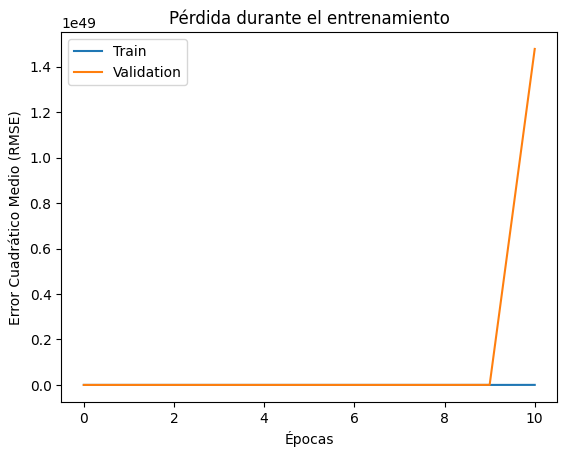

In [39]:
modelo_gradiente = LinearRegression(X_train_1, y_train, X_val_1, y_val)
modelo_gradiente.entrenar_descenso_gradiente(lr=0.01, epochs=5000)
modelo_gradiente.evaluar(X_test_1, y_test)
modelo_gradiente.graficar_regresion_descenso_gradiente(X_test_1, y_test, ["Area"])
modelo_gradiente.graficar_perdida()

#### Prueba con múltiples características

##### Pseudoinversa

In [40]:
modelo_pseudo_multi = LinearRegression(X_train, y_train, X_val, y_val)
modelo_pseudo_multi.entrenar_pseudoinversa()
modelo_pseudo_multi.evaluar(X_test, y_test)

Error cuadrático medio (RMSE) en test: 8326903.0169


8326903.016910748

##### Descenso por gradiente

Early stopping en epoch 133
Error cuadrático medio (RMSE) en test: 9362406.0320


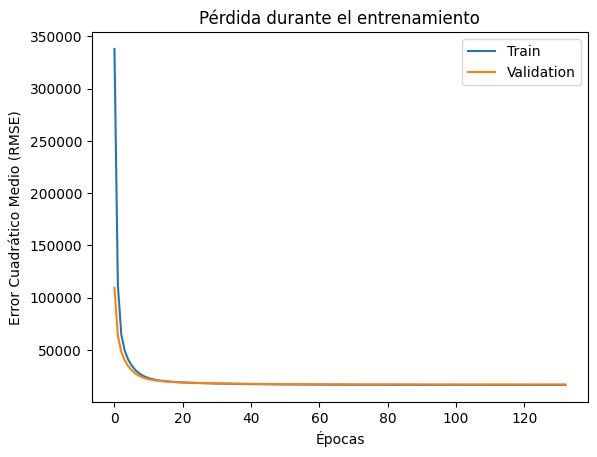

In [41]:
modelo_gradiente_multi = LinearRegression(X_train, y_train, X_val, y_val)
modelo_gradiente_multi.entrenar_descenso_gradiente(lr=0.0001, epochs=5000)
modelo_gradiente_multi.evaluar(X_test, y_test)
modelo_gradiente_multi.graficar_perdida()


en ambos casos, el método de la pseudoinversa tiene menos Error Cuadrático Medio en el set de test

### 3)

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


amanda_path = 'data/raw/vivienda_Amanda.csv'

dir_base = "data/processed/"
train_path = dir_base + "casas_train_filled_n_normalized.csv"
validation_path = dir_base + "casas_val_filled_n_normalized.csv"
test_path = dir_base + "casas_test_filled_n_normalized.csv"


# 3.1) Regresión lineal simple (Área -> Precio)
X_train, y_train, df_train = load_data(train_path, ['area'], 'price')

# Ajustar el modelo por pseudo-inversa
X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
coef_simple = np.linalg.pinv(X_train_bias) @ y_train

print("Coeficientes (Área -> Precio):", coef_simple)

# Graficar la regresión
plt.scatter(X_train, y_train, color='blue', label='Datos reales')
plt.plot(X_train, X_train_bias @ coef_simple, color='red', label='Regresión')
plt.xlabel('Área')
plt.ylabel('Precio')
plt.title('Regresión Lineal Simple (Área -> Precio)')
plt.legend()
plt.show()

# 3.2) Modelo con múltiples características
features = ['area', 'rooms', 'is_house', 'has_pool']
X_train, y_train, df_train = load_data(train_path, features, 'price')
X_test, _, df_test = load_data(test_path, features, 'price')
X_amanda, _, _ = load_data(amanda_path, features, 'price')

X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
coef_multi = np.linalg.pinv(X_train_bias) @ y_train

print("Coeficientes (Modelo Completo):", coef_multi)

# Predicción para vivienda_Amanda
X_amanda_bias = np.hstack((np.ones((X_amanda.shape[0], 1)), X_amanda))
precio_amanda = X_amanda_bias @ coef_multi
print("Predicción para vivienda Amanda:", precio_amanda)

# 3.3) Valor promedio por metro cuadrado
df_casas = pd.read_csv(train_path)
df_casas = df_casas[df_casas['is_house'] == 1]  # Solo casas
precio_m2 = df_casas['price'] / df_casas['area']
print("Valor promedio por metro cuadrado de una casa:", precio_m2.mean())

# 3.4) Impacto de una pileta en el precio
# Consideramos el coeficiente asociado a 'has_pool'
impacto_pileta = coef_multi[features.index('has_pool') + 1]
print("Impacto estimado de construir una pileta en el precio:", impacto_pileta)


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
vivienda_Amanda_df = pd.read_csv(amanda_path)
# units_vivienda_Amanda_df = area_units_conversion(vivienda_Amanda_df)
# vivienda_Amanda_scaled = scale_df(units_vivienda_Amanda_df)
# # vivienda_Amanda_transformed = pca_latlon(vivienda_Amanda_scaled)
# vivienda_Amanda_scaled.head(1)
# # vivienda_Amanda_scaled = scale_df(units_vivienda_Amanda_df, missing_values=True)



# # guardar_csv(vivienda_Amanda_transformed, "vivienda_Amanda_corregido.csv")

TypeError: scale_df() missing 1 required positional argument: 'stats'